In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml


def read_cbd(file_path):
    '''
    read_cbd: reads the cbd file data
    Arguments:
    file_path-- path where the file is located
    Return--
    dic-- data_matrix: 3-D matrix of size (N_x, N_y, N_z)
          x-coord: 1-D array of  x-coordinates size (N_x,1)
          y-coord: 1-D array of  y-coordinates size (N_y,1)
          z-coord: 1-D array of  z-coordinates size (N_z,1)
          diagonal_points: end points of the main diagonal
    '''
    f = open(file_path, "rb")
    id = np.fromfile(f, dtype=np.int64, count=1)[0]
    if id == 288230376151834571:
        T = np.float32
    elif id == 576460752303546315:
        T = np.float64
    else:
        raise ValueError("Invalid ID")
    N = tuple(np.fromfile(f, dtype=np.int64, count=3))
    xmin = tuple(np.fromfile(f, dtype=np.float64, count=3))
    xmax = tuple(np.fromfile(f, dtype=np.float64, count=3))
    x1, x2, x3 = (np.fromfile(f, dtype=np.float64, count=n) for n in N)
    data1 = np.fromfile(f, dtype=T, count=np.prod(N)).reshape(N, order="F")
    dic = {"data":data1, "x-coord":x1, "y-coord":x2, "z-coord":x3, "diagonal_points":[xmin,xmax]}
    f.close()
    return dic


def read_variables(path, timesteps, frequency):
    snaps = int(timesteps/frequency)
    # with open(path+'grid.yaml', 'r') as file:
    #     grid = yaml.load(file)
    nx = 64; ny = 64; nz = 64;
    u = np.zeros([nx, ny, nz, snaps]);
    v = np.zeros([nx, ny, nz, snaps]);
    w = np.zeros([nx, ny, nz, snaps]);
    p = np.zeros([nx, ny, nz, snaps]);

    for i in range(0,snaps):
        if i < 10:
            ut = read_cbd(path + 'u-00' + str(i) + '.cbd')
            vt = read_cbd(path + 'v-00' + str(i) + '.cbd')
            wt = read_cbd(path + 'w-00' + str(i) + '.cbd')
            pt = read_cbd(path + 'p-00' + str(i) + '.cbd')
            u[:, :, :, i] = ut['data']
            v[:, :, :, i] = vt['data']
            w[:, :, :, i] = wt['data']
        else:
            ut = read_cbd(path + 'u-0' + str(i) + '.cbd')
            vt = read_cbd(path + 'v-0' + str(i) + '.cbd')
            wt = read_cbd(path + 'w-0' + str(i) + '.cbd')
            pt = read_cbd(path + 'p-0' + str(i) + '.cbd')
            u[:, :, :, i] = ut['data']
            v[:, :, :, i] = vt['data']
            w[:, :, :, i] = wt['data']

    return u,v,w,p


## Establish File Path
sim = 'test/'
file_path = '/scratch/general/lustre/u0851921/sim'
output_loc = 'output/instantaneous-fields/'
path = file_path+sim+output_loc
timesteps = 100000
frequency = 5000

u,v,w,p = read_variables(path,timesteps,frequency)


uavg = np.mean(np.mean(np.mean(u[:,:,:,:],3),0),1)
z = np.linspace(0,1000,64)
plt.figure
plt.plot(uavg,z)
plt.show()

<Figure size 640x480 with 1 Axes>

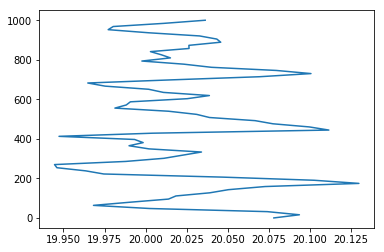

In [2]:
plt.figure
plt.plot(uavg,z)
plt.show()